In [1]:
#Se importan todas las librerias necesarias o a utilizar.
import mne
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy import signal # Nos permite realizar preprocesmaiento de la señal
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu

## **Practica 3**
## **Parte 2 (EEG)**

## **1. Obtencion y procesamiento de los datos.**

In [2]:
runs_validos = ['R04','R08','R12'] #Corresponden a "Task 2 (imagine opening and closing left or right fist)".
ruta_base = r"C:\UdeA\Semestre 20261\Bioseñales\files"
#ruta_base = r"C:/Users/david/OneDrive/Desktop/Archivos Bioseñales/EEG" 

In [3]:
# obtener solo carpetas
sujetos = [s for s in os.listdir(ruta_base) if os.path.isdir(os.path.join(ruta_base, s))] 

# Se ordenan
sujetos.sort()

# tomar solo 10
sujetos = sujetos[:10]

#Diccionario libre para llenar con los datos que se van a obtener
datos = {}

for sujeto in sujetos:
    
    ruta_sujeto = os.path.join(ruta_base, sujeto)
    
    raws = []
    
    for archivo in os.listdir(ruta_sujeto):
        #Aqui solo se toman los runs validos que se definieron con antelacion
        if archivo.endswith('.edf') and any(r in archivo for r in runs_validos):
            
            ruta_archivo = os.path.join(ruta_sujeto, archivo)
            raw = mne.io.read_raw_edf(ruta_archivo, preload=True, verbose=False)
            raws.append(raw) 
    
    if raws:
        datos[sujeto] = mne.concatenate_raws(raws) #Aqui se unen todas las runs en una sola 

print("Sujetos usados:", list(datos.keys())) #Aqui se ve que sujetos se van a usar y que fueron obtenidos despues del filtro.

Sujetos usados: ['S001', 'S002', 'S003', 'S004', 'S005', 'S006', 'S007', 'S008', 'S009', 'S010']


In [4]:
#Codificando la informacion obtenida
mapping = {
    'T0': 'Rest',
    'T1': 'Imagine_Left',
    'T2': 'Imagine_Right'}

datos_epochs = {}


for sujeto in datos:
    
    raw = datos[sujeto]
    
    print("Procesando:", sujeto)
    
    #Se convierten las anotaciones en una matriz de eventos que MNE entienda
    events, event_id = mne.events_from_annotations(
        raw,
        event_id={'T0': 1, 'T1': 2, 'T2': 3}
    )
    
    #Se corta la señal en epocas se usa 1 segundo antes del marcador y 4 segundos después
    epochs = mne.Epochs(
        raw,
        events,
        event_id={'T1': 2, 'T2': 3}, 
        tmin=-1.0,
        tmax=4.0,
        baseline=None,          
        preload=True,
        verbose=False
    )
    
    # Se guardan los valores
    datos_epochs[sujeto] = {
        'T1': epochs['T1'],
        'T2': epochs['T2']
    }

Procesando: S001
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S002
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S003
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S004
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S005
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S006
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S007
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S008
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S009
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]
Procesando: S010
Used Annotations descriptions: [np.str_('T0'), np.str_('T1'), np.str_('T2')]


In [5]:
conteo = []

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    #Con esto cuento, cuantas epocas hay en cada estudio.
    conteo.append({
        'Sujeto': sujeto,
        'T1': len(epochs_T1),
        'T2': len(epochs_T2)
    })

df_conteo = pd.DataFrame(conteo)

print(df_conteo)

  Sujeto  T1  T2
0   S001  23  22
1   S002  23  22
2   S003  23  22
3   S004  23  22
4   S005  21  24
5   S006  24  21
6   S007  23  22
7   S008  22  23
8   S009  24  21
9   S010  24  21


## **2. Cálculo de la Amplitud Efectiva (RMS)**

In [6]:
#Se procede a calcular el valor rms de cada canal, esto me habla de la energia de cada canal.
def calcular_rms_por_canal(data):
    """
    data: (epocas, canales, muestras)
    retorna: (canales,)
    """
    rms_epoca = np.sqrt(np.mean(data**2, axis=2))   # (epocas, canales)
    rms_promedio = np.mean(rms_epoca, axis=0)       # (canales,)
    
    return rms_promedio

In [7]:
rms_T1 = {}
rms_T2 = {}

for sujeto in datos_epochs:
    
    epochs_T1 = datos_epochs[sujeto]['T1']
    epochs_T2 = datos_epochs[sujeto]['T2']
    
    data_T1 = epochs_T1.get_data()
    data_T2 = epochs_T2.get_data()
    
    # calcular RMS
    rms_T1[sujeto] = calcular_rms_por_canal(data_T1) 
    rms_T2[sujeto] = calcular_rms_por_canal(data_T2)

## **3. Construcción de la Base de Datos Poblacional**

In [8]:
canales = epochs_T1.ch_names #Se obtiene el nombre de los canales o electrodos usados

In [9]:
df_T1 = pd.DataFrame.from_dict(rms_T1, orient='index', columns=canales) 
df_T2 = pd.DataFrame.from_dict(rms_T2, orient='index', columns=canales) #Se guardan en DataFrames 

In [10]:
print(f" Tamaño de los datos del DataFrame de la prueba T1: {df_T1.shape}") #Se imprimen el tamaño
print(f" Tamaño de los datos del DataFrame de la prueba T2: {df_T2.shape}")

print("----------------------------------------------------------------------------------------")

print("DataFrame completo de la prueba T1")
print(df_T1) #Solo se imprime uno como para ver como esta organizado, el T2 sera igual.

 Tamaño de los datos del DataFrame de la prueba T1: (10, 64)
 Tamaño de los datos del DataFrame de la prueba T2: (10, 64)
----------------------------------------------------------------------------------------
DataFrame completo de la prueba T1
          Fc5.      Fc3.      Fc1.      Fcz.      Fc2.      Fc4.      Fc6.  \
S001  0.000048  0.000049  0.000050  0.000052  0.000049  0.000043  0.000039   
S002  0.000021  0.000020  0.000020  0.000021  0.000019  0.000018  0.000016   
S003  0.000069  0.000066  0.000062  0.000062  0.000060  0.000060  0.000061   
S004  0.000032  0.000028  0.000037  0.000026  0.000026  0.000026  0.000026   
S005  0.000065  0.000029  0.000045  0.000041  0.000033  0.000041  0.000041   
S006  0.000034  0.000022  0.000023  0.000021  0.000022  0.000021  0.000026   
S007  0.000038  0.000039  0.000039  0.000038  0.000039  0.000038  0.000036   
S008  0.000037  0.000037  0.000035  0.000033  0.000033  0.000033  0.000036   
S009  0.000105  0.000083  0.000076  0.000079  0.0000

## **4. Identificación de Canales Diferenciales mediante Análisis Estadístico**

In [11]:
resultados = []

for canal in df_T1.columns:
    
    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # --- 1. Normalidad ---
    p_shapiro_1 = round(shapiro(grupo1)[1],5)
    
    if p_shapiro_1 > 0.05:
        significado_1 = "NORMALES"
    else:
        significado_1 = "NO_NORMALES"
    
    p_shapiro_2 = round(shapiro(grupo2)[1],5)

    if p_shapiro_2 > 0.05:
        significado_2 = "NORMALES"
    else:
        significado_2 = "NO_NORMALES"    

    normal = (p_shapiro_1 > 0.05) and (p_shapiro_2 > 0.05)
    
    
    resultados.append({
        'Canal': canal,
        'p_shapiro_T1': p_shapiro_1,
        'Resultado_s_T1': significado_1,
        'p_shapiro_T2': p_shapiro_2,
        'Resultado_s_T2': significado_2,
    })

df_resultados = pd.DataFrame(resultados)

df_resultados

,Canal,p_shapiro_T1,Resultado_s_T1,p_shapiro_T2,Resultado_s_T2
0,Fc5.,0.01342,NO_NORMALES,0.00397,NO_NORMALES
1,Fc3.,0.01297,NO_NORMALES,0.00309,NO_NORMALES
2,Fc1.,0.00132,NO_NORMALES,0.00043,NO_NORMALES
3,Fcz.,0.00484,NO_NORMALES,0.00132,NO_NORMALES
4,Fc2.,0.06594,NORMALES,0.01622,NO_NORMALES
...,...,...,...,...,...
59,Po8.,0.00018,NO_NORMALES,0.00004,NO_NORMALES
60,O1..,0.00116,NO_NORMALES,0.00023,NO_NORMALES
61,Oz..,0.00082,NO_NORMALES,0.00016,NO_NORMALES
62,O2..,0.00012,NO_NORMALES,0.00005,NO_NORMALES


In [18]:
Canales_Normales_T1 = df_resultados[df_resultados['Resultado_s_T1'] == "NORMALES" ]
Canales_Normales_T1= Canales_Normales_T1.drop(columns=['p_shapiro_T2','Resultado_s_T2']).reset_index()
Canales_Normales_T1= Canales_Normales_T1.drop(columns=['index'])
#-------------------------------------------------------------------------------------------

Canales_Normales_T2 = df_resultados[df_resultados['Resultado_s_T2'] == "NORMALES" ]
Canales_Normales_T2= Canales_Normales_T2.drop(columns=['p_shapiro_T1','Resultado_s_T1']).reset_index()
Canales_Normales_T2= Canales_Normales_T2.drop(columns=['index'])
#----------------------------------------------------------------------------------------

Canales_NO_Normales_T1 = df_resultados[df_resultados['Resultado_s_T1'] == "NO_NORMALES" ]
Canales_NO_Normales_T1= Canales_NO_Normales_T1.drop(columns=['p_shapiro_T2','Resultado_s_T2']).reset_index()
Canales_NO_Normales_T1= Canales_NO_Normales_T1.drop(columns=['index'])
#--------------------------------------------------------------------------------------------------

Canales_NO_Normales_T2 = df_resultados[df_resultados['Resultado_s_T2'] == "NO_NORMALES" ]
Canales_NO_Normales_T2= Canales_NO_Normales_T2.drop(columns=['p_shapiro_T1','Resultado_s_T1']).reset_index()
Canales_NO_Normales_T2= Canales_NO_Normales_T2.drop(columns=['index'])

In [ ]:
resultados_1 = []

# solo canales que existen en ambos
canales_comunes = df_T1.columns.intersection(df_T2.columns)

for canal in canales_comunes:
    
    grupo1 = df_T1[canal]
    grupo2 = df_T2[canal]
    
    # --- Levene ---
    p_levene = round(levene(grupo1, grupo2)[1], 5)
    
    if p_levene > 0.05:
        significado_3 = "HOMOCEDASTICO"
    else:
        significado_3 = "NO_HOMOCEDASTICO"
    
    if  p_levene > 0.05:

        # --- t-test ---
        p_t = round(ttest_ind(grupo1, grupo2)[1], 5)
        
        resultado_t = "DIFERENCIA" if p_t <= 0.05 else "NO_DIFERENCIA"
    else:
        p_t = "NO_APLICA"    
        resultado_t = "NO_APLICA"    

    resultados_1.append({
        'Canal': canal,
        'p_levene': p_levene,
        'Resultado_l': significado_3,
        'p_ttest': p_t,
        'Resultado_t': resultado_t
    })

df_resultados1 = pd.DataFrame(resultados_1)

df_resultados1

In [13]:
# --- 3. Prueba estadística ---
if normal and homocedastico:
stat, p_valor = round(ttest_ind(grupo1, grupo2),5)
prueba = 't-test'

if p_valor > 0.05:
    
else:
stat, p_valor = mannwhitneyu(grupo1, grupo2)
prueba = 'Mann-Whitney'

# --- 2. Homocedasticidad ---
p_levene = round(levene(grupo1, grupo2)[1],5)
if p_levene > 0.05:
significado_3 = "HOMOCEDASTICO"
else:
significado_3 = "NO_HOMOCEDASTICO"

homocedastico = p_levene > 0.05

IndentationError: expected an indented block after 'if' statement on line 2 (2436708920.py, line 3)

In [ ]:
significativos = df_resultados[df_resultados['p_valor'] < 0.05]

print(significativos[['Canal', 'Prueba', 'p_valor']])

Empty DataFrame
Columns: [Canal, Prueba, p_valor]
Index: []


In [ ]:
canal_top = df_resultados.sort_values('p_valor').iloc[0]['Canal']
print("Canal más significativo:", canal_top)

Canal más significativo: F8..


C:\Users\randy\AppData\Local\Temp\ipykernel_7316\1452230539.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


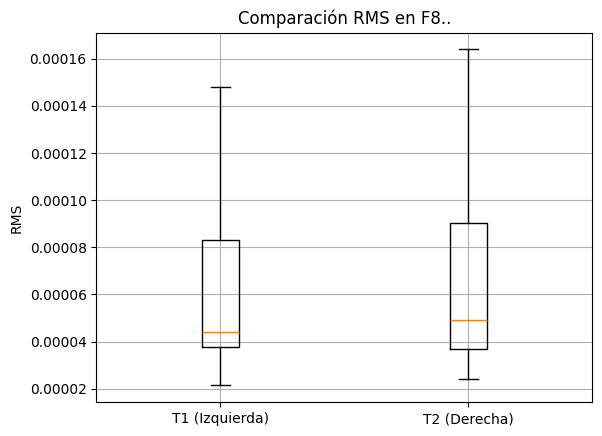

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot(
    [df_T1[canal_top], df_T2[canal_top]],
    labels=['T1 (Izquierda)', 'T2 (Derecha)']
)

plt.title(f'Comparación RMS en {canal_top}')
plt.ylabel('RMS')

plt.grid()
plt.show()

NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...
NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


C:\Users\randy\AppData\Local\Temp\ipykernel_7316\904991690.py:3: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs_T1.plot_psd(fmin=7, fmax=30, picks=['C3..', 'C4..'])
C:\Users\randy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)
C:\Users\randy\AppData\Local\Temp\ipykernel_7316\904991690.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  epochs_T2.plot_psd(fmin=7, fmax=30, picks=['C3..', 'C4..'])
C:\Users\randy\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


Text(0.5, 1.0, 'Espectro de Frecuencia - Mano Derecha (T3)')

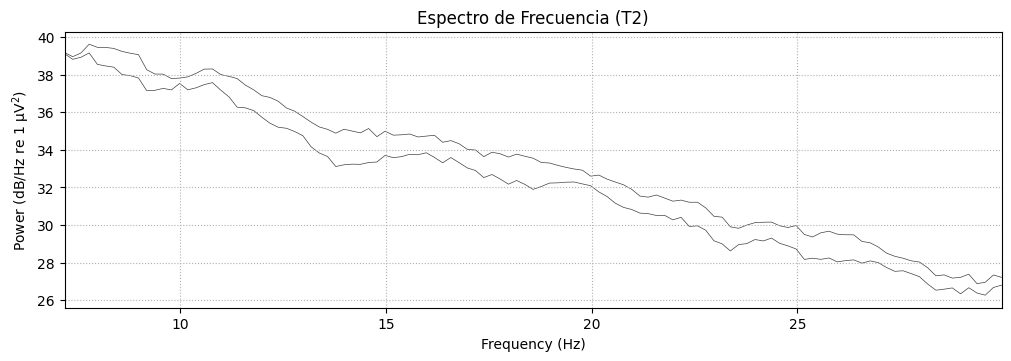

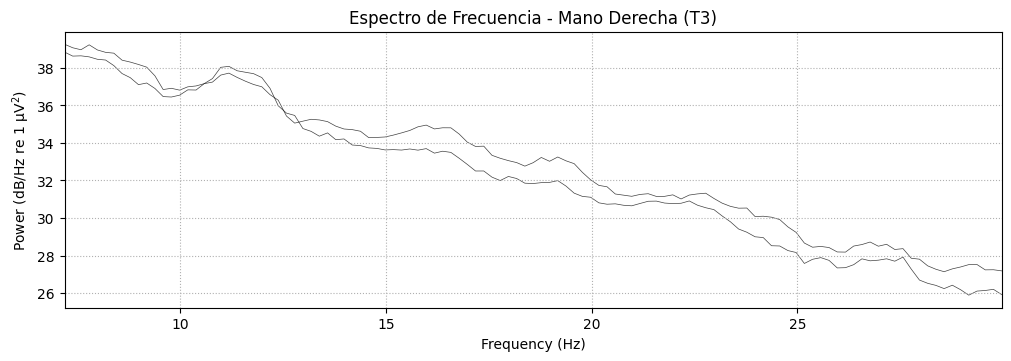

In [ ]:
# 1. Graficar el espectro de potencia (PSD) para comparar T1 vs T2
# Esto nos dirá si realmente filtramos bien y dónde está la energía Mu
epochs_T1.plot_psd(fmin=7, fmax=30, picks=['C3..', 'C4..'])
plt.title("Espectro de Frecuencia (T2)")

epochs_T2.plot_psd(fmin=7, fmax=30, picks=['C3..', 'C4..'])
plt.title("Espectro de Frecuencia - Mano Derecha (T3)")

C:\Users\randy\AppData\Local\Temp\ipykernel_7316\28647344.py:7: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked_left.plot(picks=['C3..', 'C4..'], axes=ax[0], spatial_colors=True, show=False)
C:\Users\randy\AppData\Local\Temp\ipykernel_7316\28647344.py:9: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  evoked_right.plot(picks=['C3..', 'C4..'], axes=ax[1], spatial_colors=True, show=False)


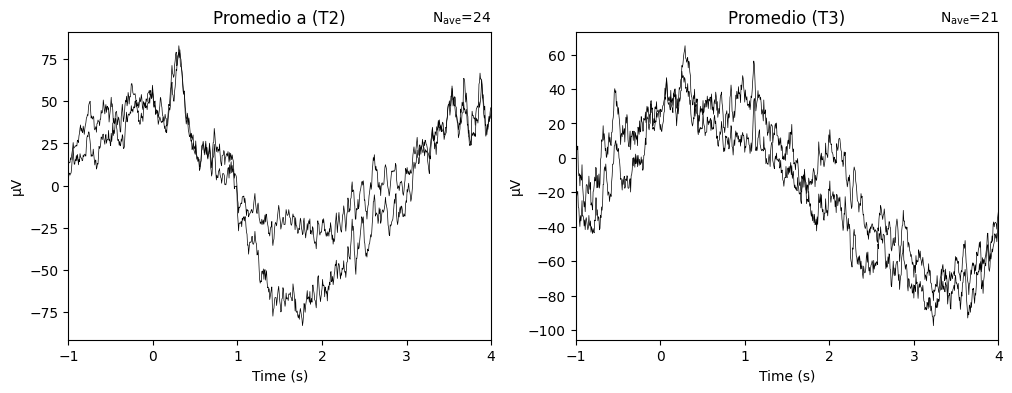

In [ ]:
# Creamos los promedios (evocados)
evoked_left = epochs_T1.average()
evoked_right = epochs_T2.average()

# Los comparamos en los canales motores
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
evoked_left.plot(picks=['C3..', 'C4..'], axes=ax[0], spatial_colors=True, show=False)
ax[0].set_title('Promedio a (T2)')
evoked_right.plot(picks=['C3..', 'C4..'], axes=ax[1], spatial_colors=True, show=False)
ax[1].set_title('Promedio (T3)')
plt.show()